## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000012E85E82310> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2024_filled_mean_rain.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [5]:
timeline_file.head()

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan
0,0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-01,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13676.000000,0.001530,1,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.001530,0.001530,0.001530,0.001530
1,1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-02,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13755.000000,0.310446,2,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.311976,0.311976,0.311976,0.311976
2,2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-03,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13755.000000,0.512597,3,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574
3,3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-04,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.000000,13905.000000,0.000000,4,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574
4,4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-05,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.000000,13905.000000,0.000000,5,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574


In [6]:
timeline_file.shape

(181775, 38)

In [7]:
# wnv_file.head()

In [8]:
# wnv_file.shape

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [11]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [12]:
# dataset_list = []
# groups = timeline_file.groupby(['x', 'y', 'year'])

# for group, data in groups:
#     temp_df = data.copy()
#     temp_df.reset_index(drop=True, inplace=True)
#     temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
#     temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
#     temp_df['acc_rainfall_month'] = temp_df['rainfall'].rolling(window=30, min_periods=0).sum()
#     temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
#     dataset_list.append(temp_df)

# dataset = pd.concat(dataset_list, ignore_index=True)
# dataset.reset_index(drop=True, inplace=True)

In [13]:
dataset = timeline_file.copy()

In [14]:
dataset.dtypes

Unnamed: 0                     int64
NUTS2_ID                      object
NUTS2_NAME                    object
NUTS3_ID                      object
NUTS3_NAME                    object
x                            float64
y                            float64
dt_placement          datetime64[ns]
year                           int64
month                          int64
ndvi                         float64
ndmi                         float64
ndwi                         float64
ndbi                         float64
ndvi_mean                    float64
ndmi_mean                    float64
ndwi_mean                    float64
ndbi_mean                    float64
ndvi_std                     float64
ndmi_std                     float64
ndwi_std                     float64
ndbi_std                     float64
lst_day                      float64
lst_night                    float64
rainfall                     float64
day                            int64
lst_jan_day_mean             float64
l

In [15]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))

In [16]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [17]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [18]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [19]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<Axes: >

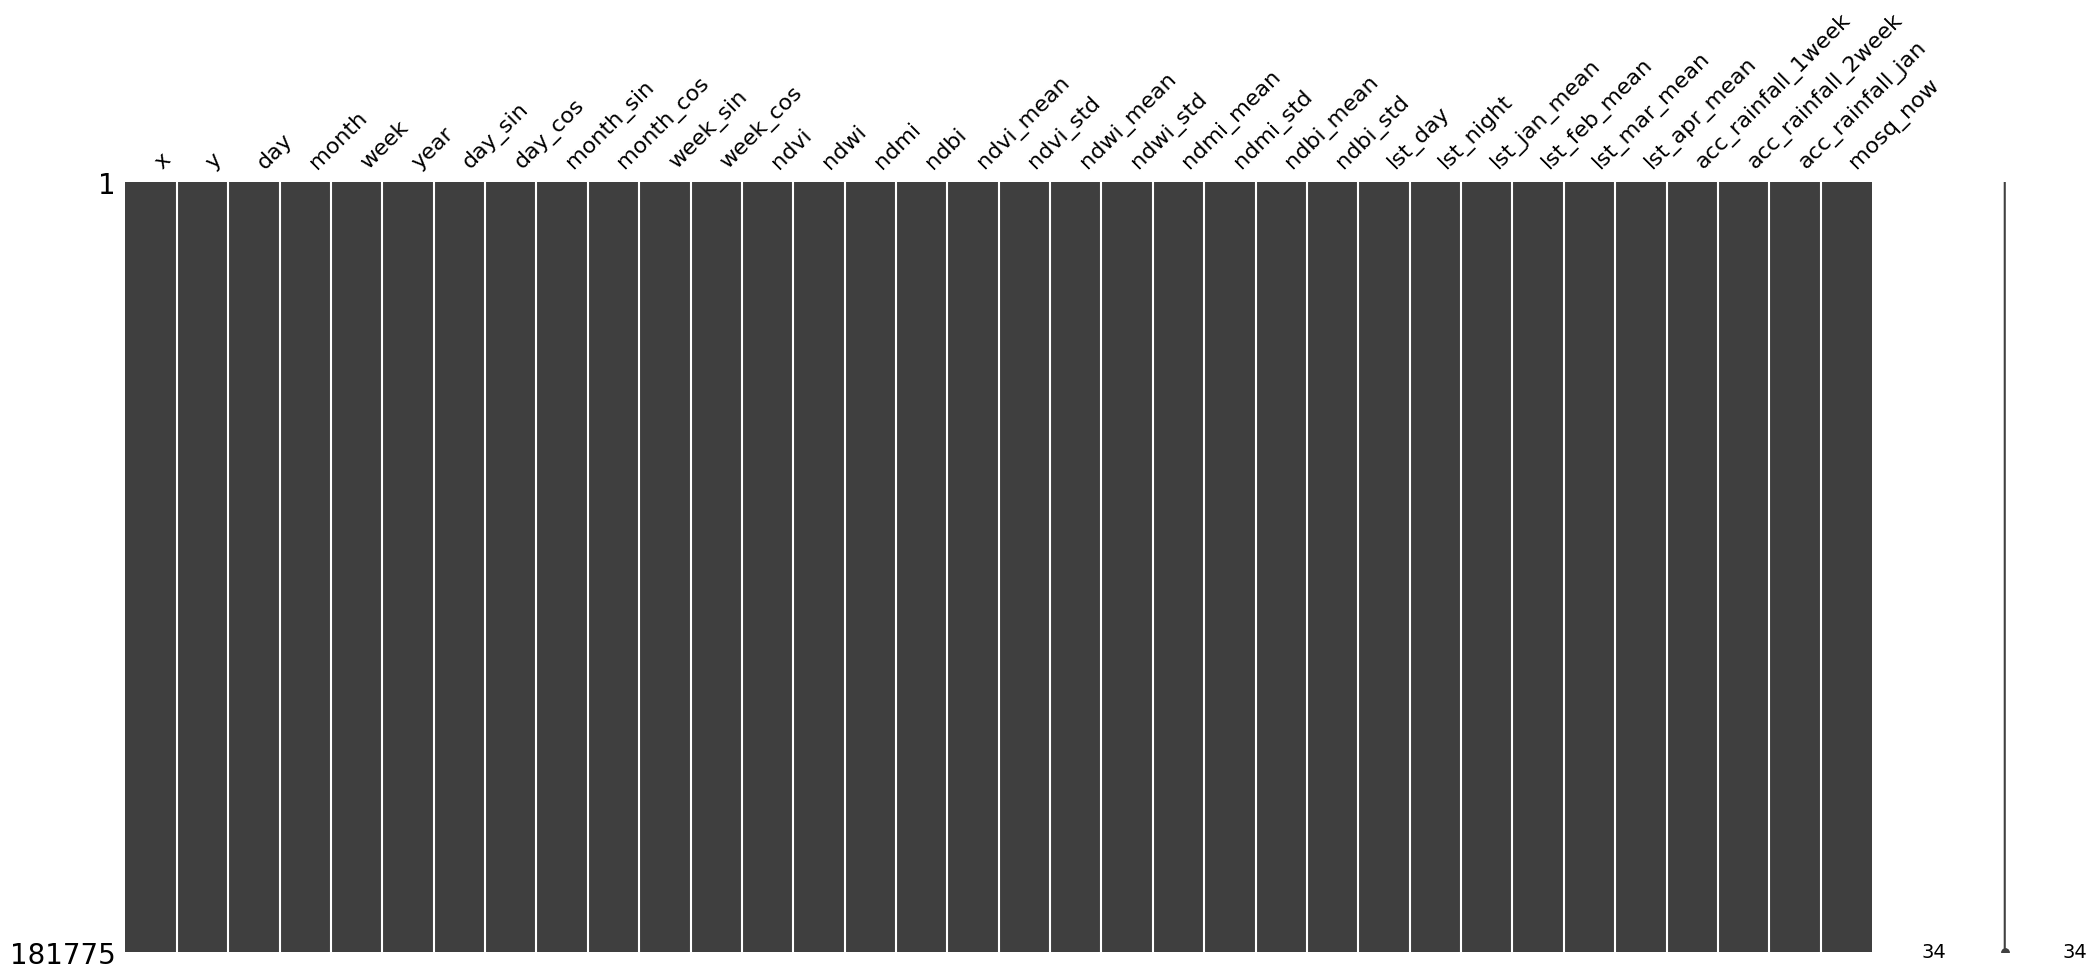

In [20]:
missingno.matrix(dataset_mamoth)

In [21]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [22]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [23]:
predictions = give_predictions(model, dataset_mamoth)

In [24]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.694820,41.344930,2024-01-01,65
1,23.694820,41.344930,2024-01-02,64
2,23.694820,41.344930,2024-01-03,65
3,23.694820,41.344930,2024-01-04,54
4,23.694820,41.344930,2024-01-05,54
...,...,...,...,...
181770,26.605580,41.380340,2024-09-27,65
181771,26.605580,41.380340,2024-09-28,68
181772,26.605580,41.380340,2024-09-29,64
181773,26.605580,41.380340,2024-09-30,53


<Axes: >

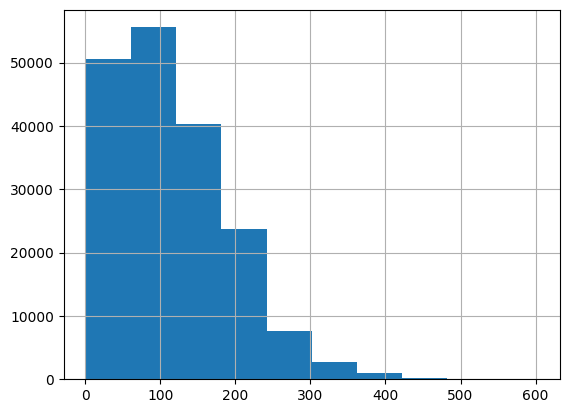

In [25]:
mosqutio_predictions.mosq_pred.hist()

In [26]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2024.csv", encoding = enc, index = False)

# mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
# mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

#dataset = timeline_file

In [27]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [28]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-01,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13676.000000,0.001530,1,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.001530,0.001530,0.001530,0.001530,13837.000000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,65
1,1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-02,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13755.000000,0.310446,2,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.311976,0.311976,0.311976,0.311976,13876.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,64
2,2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-03,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13755.000000,0.512597,3,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574,13876.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,65
3,3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-04,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.000000,13905.000000,0.000000,4,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574,13830.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,54
4,4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-05,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.000000,13905.000000,0.000000,5,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574,13830.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181770,181770,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.605580,41.380340,2024-09-27,2024,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15357.000000,14536.000000,NaN,27,14086.249032,13726.772419,14341.048276,13920.649138,14444.408548,13928.651290,14865.151500,14220.632667,0.000000,0.000000,0.000000,160.586929,14946.500000,13906.510726,14130.848707,14186.529919,14542.892083,39,-0.724793,0.688967,-1.000000,-0.000000,-0.996050,-0.088796,65
181771,181771,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.605580,41.380340,2024-09-28,2024,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15116.000000,14538.000000,NaN,28,14086.249032,13726.772419,14341.048276,13920.649138,14444.408548,13928.651290,14865.151500,14220.632667,0.0

In [29]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [30]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [31]:
dataset_locations

,x,y
0,23.694820,41.344930
1,23.694820,41.380860
2,23.742410,41.237130
3,23.742410,41.344930
4,23.790000,41.201190
...,...,...
656,26.558400,41.452200
657,26.558400,41.488140
658,26.558400,41.524070
659,26.558400,41.560000


In [32]:
dataset_locations_per_year

,x,y,year
0,23.694820,41.344930,2024
1,23.694820,41.380860,2024
2,23.742410,41.237130,2024
3,23.742410,41.344930,2024
4,23.790000,41.201190,2024
...,...,...,...
656,26.558400,41.452200,2024
657,26.558400,41.488140,2024
658,26.558400,41.524070,2024
659,26.558400,41.560000,2024


In [33]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [34]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0


In [35]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_24108\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [36]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.694820,41.344930,11370.706859,549.918143,20,165.900164,799.846093,174.694146,0.000000,1.304286
1,23.694820,41.380860,13829.383567,2674.249604,12,118.658283,894.807148,157.249006,0.000000,2.801723
2,23.742410,41.237130,7636.748691,1197.955387,16,192.555437,944.094059,204.343017,0.000000,3.085875
3,23.742410,41.344930,8194.676125,1257.421887,15,171.328287,716.732079,174.441758,0.000000,1.607124
4,23.790000,41.201190,8700.608465,1540.788376,21,105.033096,851.252007,124.148070,0.000000,3.680365
...,...,...,...,...,...,...,...,...,...,...
656,26.558400,41.452200,12785.394171,693.497313,7,101.416658,28.931503,178.253123,0.000000,2.505041
657,26.558400,41.488140,14184.704295,796.163411,1,139.300111,23.695790,180.018704,0.000000,1.000000
658,26.558400,41.524070,10308.735178,874.994374,4,132.975201,26.214813,180.068396,0.000000,1.322014
659,26.558400,41.560000,6571.571585,671.897226,2,165.811755,27.410546,180.111632,0.000000,2.494803


In [37]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [38]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.694820,41.344930,11370.706859,549.918143,20,165.900164,799.846093,174.694146,0.000000,1.304286
1,23.694820,41.380860,13829.383567,2674.249604,12,118.658283,894.807148,157.249006,0.000000,2.801723
2,23.742410,41.237130,7636.748691,1197.955387,16,192.555437,944.094059,204.343017,0.000000,3.085875
3,23.742410,41.344930,8194.676125,1257.421887,15,171.328287,716.732079,174.441758,0.000000,1.607124
4,23.790000,41.201190,8700.608465,1540.788376,21,105.033096,851.252007,124.148070,0.000000,3.680365
...,...,...,...,...,...,...,...,...,...,...
656,26.558400,41.452200,12785.394171,693.497313,7,101.416658,28.931503,178.253123,0.000000,2.505041
657,26.558400,41.488140,14184.704295,796.163411,1,139.300111,23.695790,180.018704,0.000000,1.000000
658,26.558400,41.524070,10308.735178,874.994374,4,132.975201,26.214813,180.068396,0.000000,1.322014
659,26.558400,41.560000,6571.571585,671.897226,2,165.811755,27.410546,180.111632,0.000000,2.494803


In [41]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [42]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [43]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [44]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [45]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [46]:
landcover_2024 = landcover_2023 = landcover_2022

In [47]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2024
Min distance: 0.0
Max distance: 0.0


In [48]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [49]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,23.694820,41.344930,2024,21,74,20,74.000000,20,74,8,8,4,4,4,2,0
1,23.694820,41.380860,2024,31,90,30,90.000000,30,90,10,10,1,6,6,2,0
2,23.742410,41.237130,2024,14,98,10,98.000000,10,98,4,4,6,4,4,2,0
3,23.742410,41.344930,2024,21,73,20,73.000000,20,73,8,8,4,4,4,2,0
4,23.790000,41.201190,2024,22,78,20,78.000000,20,78,9,9,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,26.558400,41.452200,2024,31,98,9,NaN,30,98,13,13,10,8,9,2,9
657,26.558400,41.488140,2024,31,99,36,99.000000,30,99,12,12,3,5,8,2,0
658,26.558400,41.524070,2024,31,99,36,99.000000,30,99,12,12,3,5,8,2,0
659,26.558400,41.560000,2024,31,99,36,99.000000,30,99,12,12,3,5,8,2,0


In [50]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [51]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [52]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [53]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-01,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13676.000000,0.001530,1,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.001530,0.001530,0.001530,0.001530,13837.000000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,65,11370.706859,549.918143,20,165.900164,799.846093,174.694146,0.000000,1.304286,21,74,20,74.000000,20,74,8,8,4,4,4,2,0
1,1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-02,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13755.000000,0.310446,2,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.311976,0.311976,0.311976,0.311976,13876.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,64,11370.706859,549.918143,20,165.900164,799.846093,174.694146,0.000000,1.304286,21,74,20,74.000000,20,74,8,8,4,4,4,2,0
2,2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-03,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13998.000000,13755.000000,0.512597,3,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574,13876.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,65,11370.706859,549.918143,20,165.900164,799.846093,174.694146,0.000000,1.304286,21,74,20,74.000000,20,74,8,8,4,4,4,2,0
3,3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-04,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.000000,13905.000000,0.000000,4,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574,13830.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,54,11370.706859,549.918143,20,165.900164,799.846093,174.694146,0.000000,1.304286,21,74,20,74.000000,20,74,8,8,4,4,4,2,0
4,4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.344930,2024-01-05,2024,1,0.284574,-0.143870,-0.272169,0.143870,0.270964,-0.054752,-0.207973,0.054752,0.024776,0.054316,0.051266,0.054316,13756.000000,13905.000000,0.000000,5,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.824574,0.824574,0.824574,0.824574,13830.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,54,11370.706859,549.918143,20,165.900164,799.846093,174.694146,0.000000,1.304286,21,74,20,74.000000,20,74,8,8,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [54]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [55]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [56]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [57]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [58]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [59]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,111100,26.228140,40.913200,2024,1,-0.014033,-0.345912,-0.399602,-0.422797,-0.027124,-0.309884,-0.356264,-0.201380,0.000000,0.000000,0.000000,0.000000,14024.000000,14022.000000,0.000000,1,14086.249032,13726.772419,14341.048276,13920.649138,14444.408548,13928.651290,14865.151500,14220.632667,0.000000,0.000000,0.000000,0.000000,14175.000000,13906.510726,14130.848707,14186.529919,14542.892083,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,81,352.814714,2.251510,2,43.594740,1.494305,131.360703,0.000000,1.000000,31,98,36,98.000000,30,98,12,12,3,5,8,2,0
1,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,61600,24.823170,41.271320,2024,1,0.056828,-0.244746,-0.511553,-0.246859,0.026639,-0.152092,-0.490909,-0.180742,0.000000,0.000000,0.000000,0.000000,14235.000000,13878.000000,0.000000,1,14049.217742,13662.883468,14253.852586,13831.589655,14404.359274,13920.600403,14809.900833,14222.193750,0.000000,0.000000,0.000000,0.000000,14023.500000,13856.050605,14042.721121,14162.479839,14516.047292,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,116,1422.320233,2.995414,2,68.560816,3.374522,142.346950,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,3,4,4,2,0
2,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,91300,25.592780,41.127230,2024,1,-0.076023,-0.214544,-0.477707,-0.374053,-0.054775,-0.173720,-0.471947,-0.308072,0.000000,0.000000,0.000000,0.000000,14318.000000,13948.000000,0.000000,1,14099.633715,13711.818158,14306.535039,13899.578420,14459.404266,13932.547867,14842.184409,14233.125806,0.000000,0.000000,0.000000,0.000000,14125.000000,13905.725937,14103.056730,14195.976067,14537.655108,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,16,309.608445,13.084090,2,51.239071,2.443469,158.496367,0.000000,1.000000,31,89,20,91.000000,30,89,12,9,4,5,8,2,0
3,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,0,24.123120,41.344930,2024,1,-0.271630,-0.216167,-0.504278,-0.639535,-0.082265,-0.239388,-0.454710,-0.668364,0.000000,0.000000,0.000000,0.000000,14012.000000,13613.000000,0.000000,1,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.000000,0.000000,0.000000,0.000000,13730.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,28,0.000000,43.608835,1,23.772370,52.039252,124.148070,0.000000,1.000000,14,98,10,99.000000,10,99,4,4,4,4,4,2,0
4,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",6875,24.641600,41.006750,2024,1,-0.009153,-0.220474,-0.509732,-0.409158,0.067938,-0.180049,-0.457855,-0.363430,0.015369,0.017734,0.016054,0.017734,14317.000000,13994.000000,0.000000,1,14073.050747,13755.566876,14256.981918,13889.698486,14362.148308,13972.516522,14821.921138,14266.569512,0.000000,0.000000,0.000000,0.000000,14074.500000,13914.308812,14073.340202,14167.332415,14544.245325,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,15,1839.000704,25.345187,2,55.369486,3.090786,141.309259,0.000000,1.000000,31,99,20,99.000000,20,99,8,8,4,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [60]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,111100,25.567630,40.446070,2024,1,-0.014033,-0.345912,-0.399602,-0.422797,-0.027124,-0.309884,-0.356264,-0.201380,0.000000,0.000000,0.000000,0.000000,13883.000000,13601.000000,0.000000,1,14086.249032,13726.772419,14341.048276,13920.649138,14444.408548,13928.651290,14865.151500,14220.632667,0.000000,0.000000,0.000000,0.000000,13786.000000,13906.510726,14130.848707,14186.529919,14542.892083,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,7,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,1,65,1,65.000000,1,65,1,1,1,1,1,2,0
1,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,61600,24.633130,40.911990,2024,1,0.056828,-0.244746,-0.511553,-0.246859,0.026639,-0.152092,-0.490909,-0.180742,0.000000,0.000000,0.000000,0.000000,14009.000000,13786.000000,0.000000,1,14049.217742,13662.883468,14253.852586,13831.589655,14404.359274,13920.600403,14809.900833,14222.193750,0.000000,0.000000,0.000000,0.000000,13919.000000,13856.050605,14042.721121,14162.479839,14516.047292,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,2,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,14,71,9,71.000000,10,71,4,4,1,4,4,2,0
2,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,91300,25.117680,40.911630,2024,1,-0.076023,-0.214544,-0.477707,-0.374053,-0.054775,-0.173720,-0.471947,-0.308072,0.000000,0.000000,0.000000,0.000000,13815.000000,13818.000000,0.000000,1,14099.633715,13711.818158,14306.535039,13899.578420,14459.404266,13932.547867,14842.184409,14233.125806,0.000000,0.000000,0.000000,0.000000,13855.500000,13905.725937,14103.056730,14195.976067,14537.655108,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,11,66,9,66.000000,10,66,1,1,1,1,1,2,0
3,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,0,23.694820,41.057460,2024,1,-0.271630,-0.216167,-0.504278,-0.639535,-0.082265,-0.239388,-0.454710,-0.668364,0.000000,0.000000,0.000000,0.000000,13642.000000,13565.000000,0.000000,1,13917.050069,13619.718979,14162.914322,13779.140106,14311.732634,13880.081948,14751.354397,14127.758487,0.000000,0.000000,0.000000,0.000000,13662.500000,13768.384524,13971.027214,14095.907291,14439.556442,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,11,64,9,67.000000,10,67,1,1,1,1,1,1,0
4,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",6875,23.932150,40.647420,2024,1,-0.009153,-0.220474,-0.509732,-0.409158,0.067938,-0.180049,-0.457855,-0.363430,0.015369,0.017734,0.016054,0.017734,13984.000000,13706.000000,0.000000,1,14073.050747,13755.566876,14256.981918,13889.698486,14362.148308,13972.516522,14821.921138,14266.569512,0.000000,0.000000,0.000000,0.000000,13879.000000,13914.308812,14073.340202,14167.332415,14544.245325,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,3,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,11,67,9,66.000000,10,66,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [61]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean','lst_night','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_nuts3_mean[['rainfall','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan', 'mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [62]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2024,1,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,14199.495000,14086.249032,14341.048276,14444.408548,14865.151500,13964.940000,13726.772419,13920.649138,13928.651290,14220.632667,14082.217500,13906.510726,14130.848707,14186.529919,14542.892083,0.008983,0.008983,0.008983,0.008983,0.008983,118.372549,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2
1,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2024,1,0.264751,-0.070604,-0.247487,0.070604,0.229604,-0.060000,-0.205838,0.060000,0.049001,0.048458,0.067595,0.048458,14205.912500,14049.217742,14253.852586,14404.359274,14809.900833,13895.737500,13662.883468,13831.589655,13920.600403,14222.193750,14050.825000,13856.050605,14042.721121,14162.479839,14516.047292,0.000000,0.000000,0.000000,0.000000,0.000000,108.587500,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2
2,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2024,1,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,14280.967742,14099.633715,14306.535039,14459.404266,14842.184409,13970.379032,13711.818158,13899.578420,13932.547867,14233.125806,14125.673387,13905.725937,14103.056730,14195.976067,14537.655108,0.000000,0.000000,0.000000,0.000000,0.000000,93.572581,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,20,30,12,9,4,5,8,2
3,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2024,1,0.293714,0.019426,-0.248608,-0.019426,0.300071,0.016395,-0.257637,-0.016395,0.063611,0.077736,0.079891,0.077736,14067.251534,13917.050069,14162.914322,14311.732634,14751.354397,13781.159509,13619.718979,13779.140106,13880.081948,14127.758487,13924.205521,13768.384524,13971.027214,14095.907291,14439.556442,0.020961,0.020961,0.0

<Axes: >

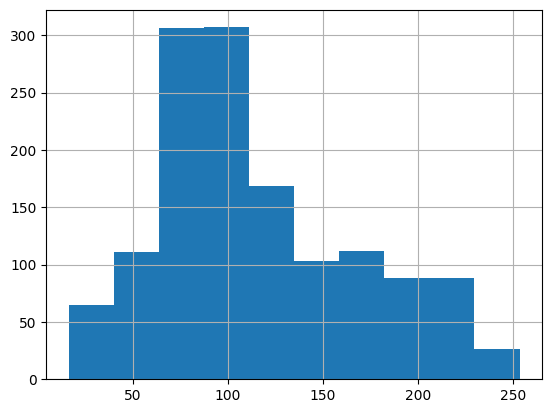

In [63]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [64]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<Axes: >

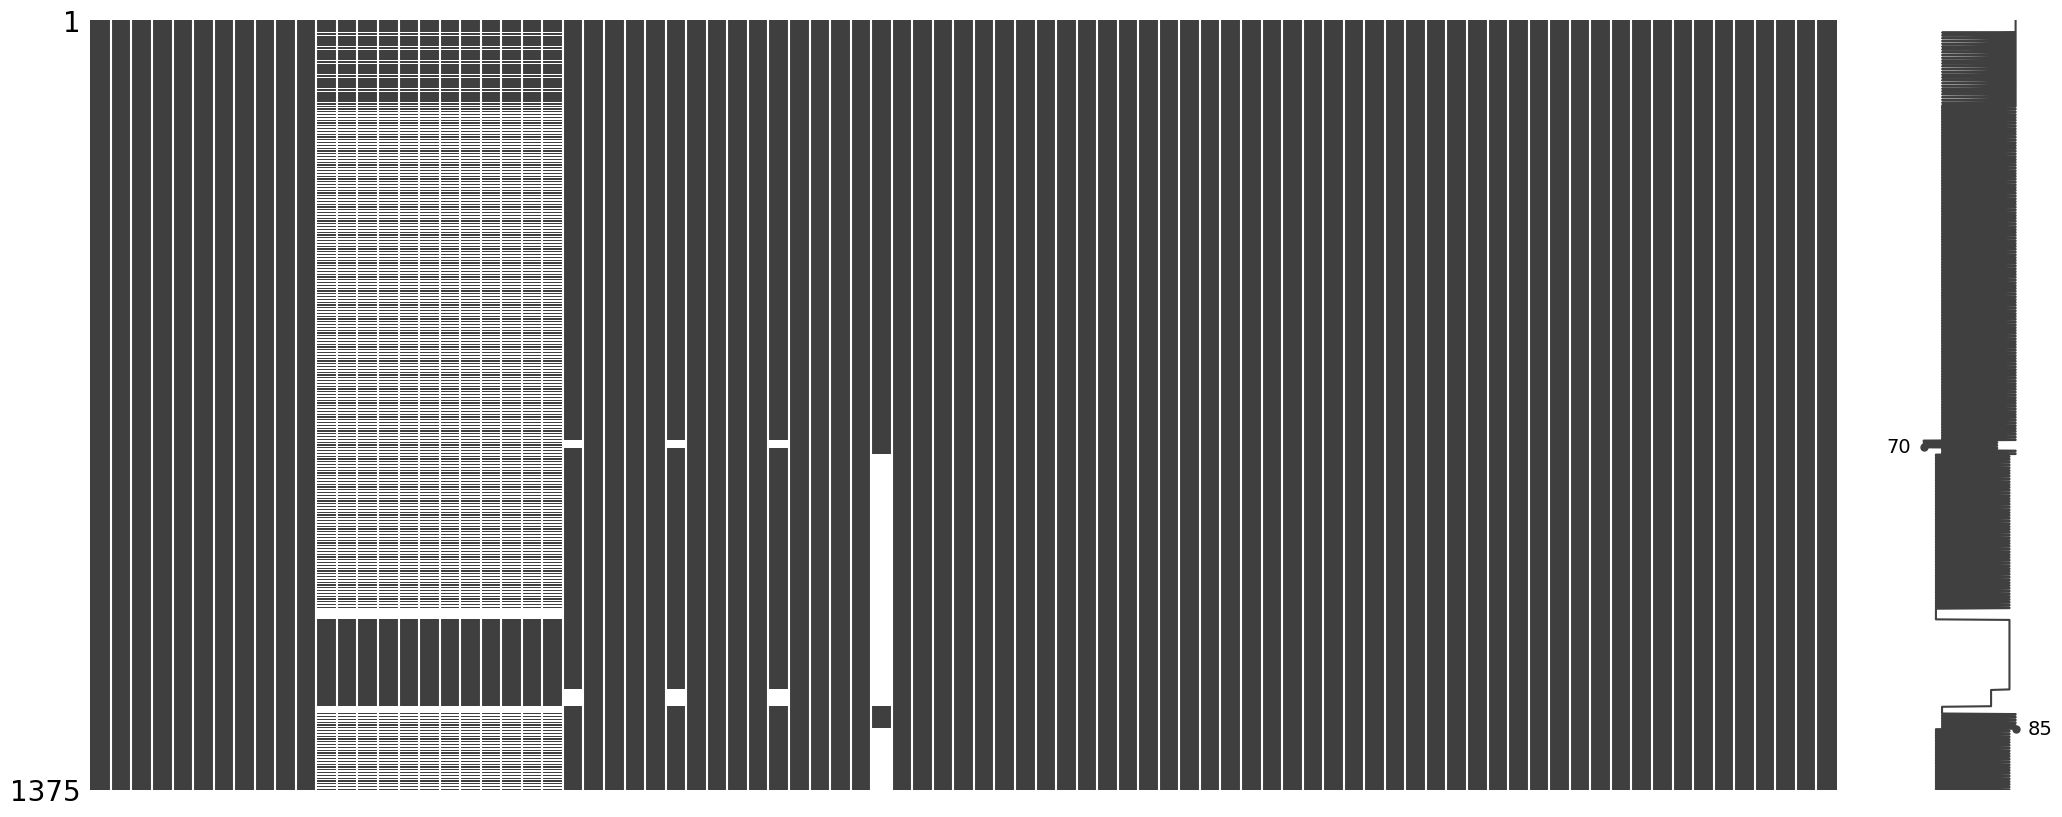

In [65]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [66]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [67]:
bio_values_df = pd.DataFrame(bio_values)

In [68]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,εβρος,2024,1,-3.237200,15.714500,14.389570
1,εβρος,2024,2,-3.237200,18.766100,29.611326
2,εβρος,2024,3,1.076800,25.613600,42.192074
3,εβρος,2024,4,8.947700,29.906100,67.972757
4,εβρος,2024,5,9.848300,29.764800,93.431967
5,εβρος,2024,6,17.563900,38.146100,0.000000
6,εβρος,2024,7,19.314200,42.630800,0.000000
7,εβρος,2024,8,21.256200,40.288500,0.000000
8,εβρος,2024,9,14.010700,35.075200,0.663444
9,εβρος,2024,10,11.674000,27.638800,0.000000


In [69]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [70]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2024,1,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,10.839900,8.574981,13.670966,15.738171,24.153030,6.148800,1.385448,5.262983,5.423026,11.262653,8.494350,4.980215,9.466974,10.580598,17.707842,0.008983,0.008983,0.008983,0.008983,0.008983,118.372549,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570
1,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2024,1,0.264751,-0.070604,-0.247487,0.070604,0.229604,-0.060000,-0.205838,0.060000,0.049001,0.048458,0.067595,0.048458,10.968250,7.834355,11.927052,14.937185,23.048017,4.764750,0.107669,3.481793,5.262008,11.293875,7.866500,3.971012,7.704422,10.099597,17.170946,0.000000,0.000000,0.000000,0.000000,0.000000,108.587500,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-3.572000,11.836250,13.078887
2,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2024,1,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,12.469355,8.842674,12.980701,16.038085,23.693688,6.257581,1.086363,4.841568,5.500957,11.512516,9.363468,4.964519,8.911135,10.769521,17.603102,0.000000,0.000000,0.000000,0.000000,0.000000,93.572581,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,20,30,12,9,4,5,8,2,-2.642097,14.367903,12.015796
3,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2024,1,0.293714,0.019426,-0.248608,-0.019426,0.300071,0.016395,-0.257637,-0.016395,0.063611,0.077736,0.079891,0.077736,8.195031,5.191001,10.108286,13.084653,21.877088,2.473190,-0.755620,2.432802,4.451639,9.405170,5.334110,2.217690,6.270544,8.768146,15.641129,0.020961,0.020961,0.020961,0.020961,0.020961,55.918129,10235.211338,1347.266180,14.339181,175.64

<Axes: >

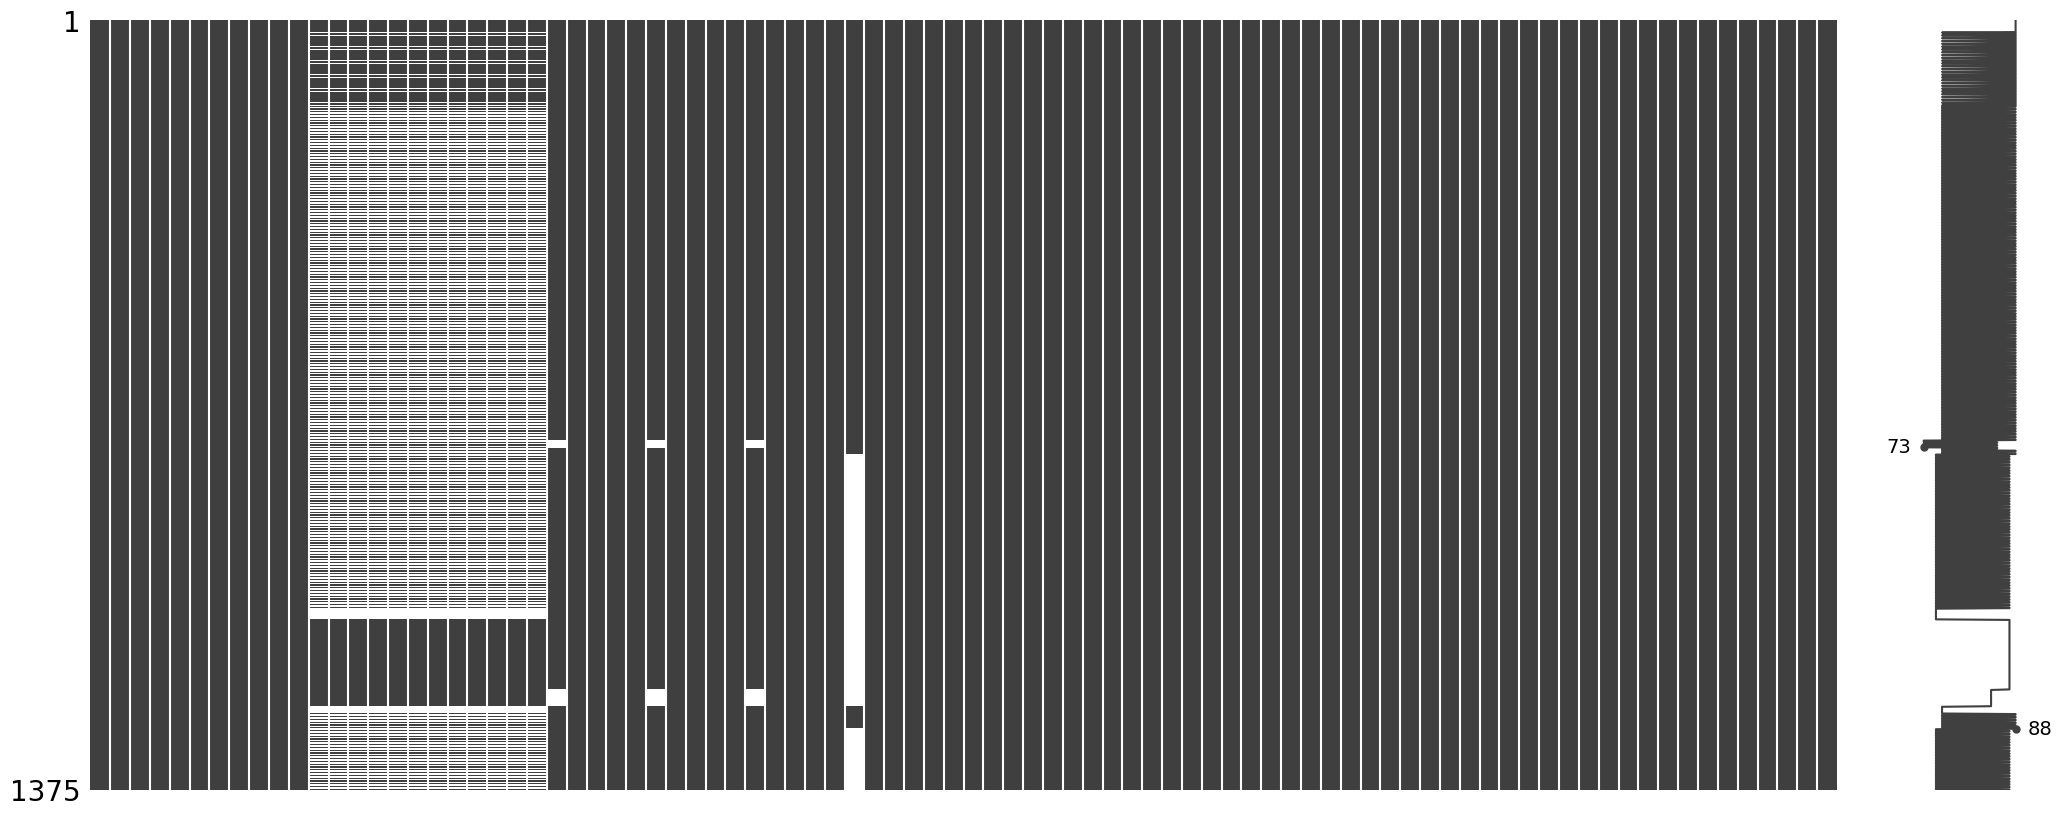

In [71]:
missingno.matrix(dataset)

In [72]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [73]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [74]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2024,1,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,10.839900,8.574981,13.670966,15.738171,24.153030,6.148800,1.385448,5.262983,5.423026,11.262653,8.494350,4.980215,9.466974,10.580598,17.707842,0.008983,0.008983,0.008983,0.008983,0.008983,118.372549,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570,2024-01
1,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2024,1,0.264751,-0.070604,-0.247487,0.070604,0.229604,-0.060000,-0.205838,0.060000,0.049001,0.048458,0.067595,0.048458,10.968250,7.834355,11.927052,14.937185,23.048017,4.764750,0.107669,3.481793,5.262008,11.293875,7.866500,3.971012,7.704422,10.099597,17.170946,0.000000,0.000000,0.000000,0.000000,0.000000,108.587500,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-3.572000,11.836250,13.078887,2024-01
2,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2024,1,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,12.469355,8.842674,12.980701,16.038085,23.693688,6.257581,1.086363,4.841568,5.500957,11.512516,9.363468,4.964519,8.911135,10.769521,17.603102,0.000000,0.000000,0.000000,0.000000,0.000000,93.572581,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,20,30,12,9,4,5,8,2,-2.642097,14.367903,12.015796,2024-01
3,2024-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2024,1,0.293714,0.019426,-0.248608,-0.019426,0.300071,0.016395,-0.257637,-0.016395,0.063611,0.077736,0.079891,0.077736,8.195031,5.191001,10.108286,13.084653,21.877088,2.473190,-0.755620,2.432802,4.451639,9.405170,5.334110,2.217690,6.270544,8.768146,15.641129,0.020961,0.020961,0.020961,0.020961,0.020961,55.91812

In [75]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2024,1,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,10.839900,8.574981,13.670966,15.738171,24.153030,-2.003400,1.385448,5.262983,5.423026,11.262653,4.847600,4.980215,9.466974,10.580598,17.707842,0.000000,0.301116,11.474867,14.088455,14.088455,39.348039,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570
1,1,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2024,1,0.247943,-0.079486,-0.239223,0.079486,0.209219,-0.064722,-0.186084,0.064722,0.049500,0.043406,0.072207,0.043406,9.149500,7.834355,11.927052,14.937185,23.048017,-3.282750,0.107669,3.481793,5.262008,11.293875,5.127000,3.971012,7.704422,10.099597,17.170946,0.000000,1.749560,2.347013,12.481433,12.481433,23.912500,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-3.572000,11.836250,13.078887
2,2,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2024,1,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,10.717581,8.842674,12.980701,16.038085,23.693688,-2.180484,1.086363,4.841568,5.500957,11.512516,6.093710,4.964519,8.911135,10.769521,17.603102,0.000000,0.574851,0.401997,11.440945,11.440945,16.016129,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,20,30,12,9,4,5,8,2,-2.642097,14.367903,12.015796
3,3,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2024,1,0.293714,0.019426,-0.248608,-0.019426,0.300071,0.016395,-0.257637,-0.016395,0.063611,0.077736,0.079891,0.077736,7.173558,5.191001,10.108286,13.084653,21.877088,4.430245,-0.755620,2.432802,4.451639,9.405170,1.497730,2.217690,6.270544,8.768146,15.641129,0.000000,0.446272,0.020961,25.845220,25.845220,27.029240,10235.211338,1347.266180,14.33

In [76]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME', 'x', 'y', 'month', 'year']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_sum[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_acc'}),
                                     grouped_by_month_mean[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_mean'}),
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [77]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2024,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,8.574981,1.385448,4.980215,8.574981,13.670966,15.738171,24.153030,1.385448,5.262983,5.423026,11.262653,4.980215,9.466974,10.580598,17.707842,0.464180,0.301116,2.139040,14.380588,14.389570,2675.583333,86.309140,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570
1,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2024,0.250112,-0.078340,-0.240289,0.078340,0.211850,-0.064113,-0.188633,0.064113,0.049435,0.044058,0.071612,0.044058,7.834355,0.107669,3.971012,7.834355,11.927052,14.937185,23.048017,0.107669,3.481793,5.262008,11.293875,3.971012,7.704422,10.099597,17.170946,0.421900,0.596450,2.341214,13.078887,13.078887,1821.350000,58.753226,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-3.572000,11.836250,13.078887
2,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2024,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,8.842674,1.086363,4.964519,8.842674,12.980701,16.038085,23.693688,1.086363,4.841568,5.500957,11.512516,4.964519,8.911135,10.769521,17.603102,0.387606,0.574626,2.705965,12.015796,12.015796,1564.612903,50.471384,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,20,30,12,9,4,5,8,2,-2.642097,14.367903,12.015796
3,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,2024,0.289399,0.045657,-0.249434,-0.045657,0.290606,0.044728,-0.253649,-0.044728,0.058700,0.077047,0.071844,0.077047,5.191001,-0.755620,2.217690,5.191001,10.108286,13.084653,21.877088,-0.755620,2.432802,4.451639,9.405170,2.217690,6.270544,8.768146,15.641129,0.848188,0.399525,6.824255,26.272857,26.293817,1322.7894

In [78]:
# wnv_file.head(5)

In [79]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            50 non-null     period[M]
 1   NUTS2_ID                50 non-null     object   
 2   NUTS2_NAME              50 non-null     object   
 3   NUTS3_ID                50 non-null     object   
 4   NUTS3_NAME              50 non-null     object   
 5   x                       50 non-null     float64  
 6   y                       50 non-null     float64  
 7   month                   50 non-null     int64    
 8   year                    50 non-null     int64    
 9   ndvi                    29 non-null     float64  
 10  ndmi                    29 non-null     float64  
 11  ndwi                    29 non-null     float64  
 12  ndbi                    29 non-null     float64  
 13  ndvi_mean               29 non-null     float64  
 14  ndmi_mean   

In [80]:
# wnv_file.info()

In [81]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [82]:
# wnv_file

In [83]:
# wnv_file['cases'].value_counts()

In [84]:
# wnv_file.cases.sum()

In [85]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )
merged = grouped_by_month_dataset.copy()

In [86]:
merged['cases'] = 0

In [87]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2024,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,8.574981,1.385448,4.980215,8.574981,13.670966,15.738171,24.153030,1.385448,5.262983,5.423026,11.262653,4.980215,9.466974,10.580598,17.707842,0.464180,0.301116,2.139040,14.380588,14.389570,2675.583333,86.309140,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570,0
1,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2024,0.250112,-0.078340,-0.240289,0.078340,0.211850,-0.064113,-0.188633,0.064113,0.049435,0.044058,0.071612,0.044058,7.834355,0.107669,3.971012,7.834355,11.927052,14.937185,23.048017,0.107669,3.481793,5.262008,11.293875,3.971012,7.704422,10.099597,17.170946,0.421900,0.596450,2.341214,13.078887,13.078887,1821.350000,58.753226,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-3.572000,11.836250,13.078887,0
2,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2024,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,8.842674,1.086363,4.964519,8.842674,12.980701,16.038085,23.693688,1.086363,4.841568,5.500957,11.512516,4.964519,8.911135,10.769521,17.603102,0.387606,0.574626,2.705965,12.015796,12.015796,1564.612903,50.471384,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,20,30,12,9,4,5,8,2,-2.642097,14.367903,12.015796,0
3,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,2024,0.289399,0.045657,-0.249434,-0.045657,0.290606,0.044728,-0.253649,-0.044728,0.058700,0.077047,0.071844,0.077047,5.191001,-0.755620,2.217690,5.191001,10.108286,13.084653,21.877088,-0.755620,2.432802,4.451639,9.405170,2.217690,6.270544,8.768146,15.641129,0.848188,0.399525,6.824255,26.272857,26.2938

In [88]:
merged = fillna(merged,{'cases': 0})

In [89]:
merged['cases'].value_counts()

cases
0    50
Name: count, dtype: int64

In [90]:
merged.cases.sum()

0

In [91]:
merged = merged.astype({'cases': 'int'})

<Axes: >

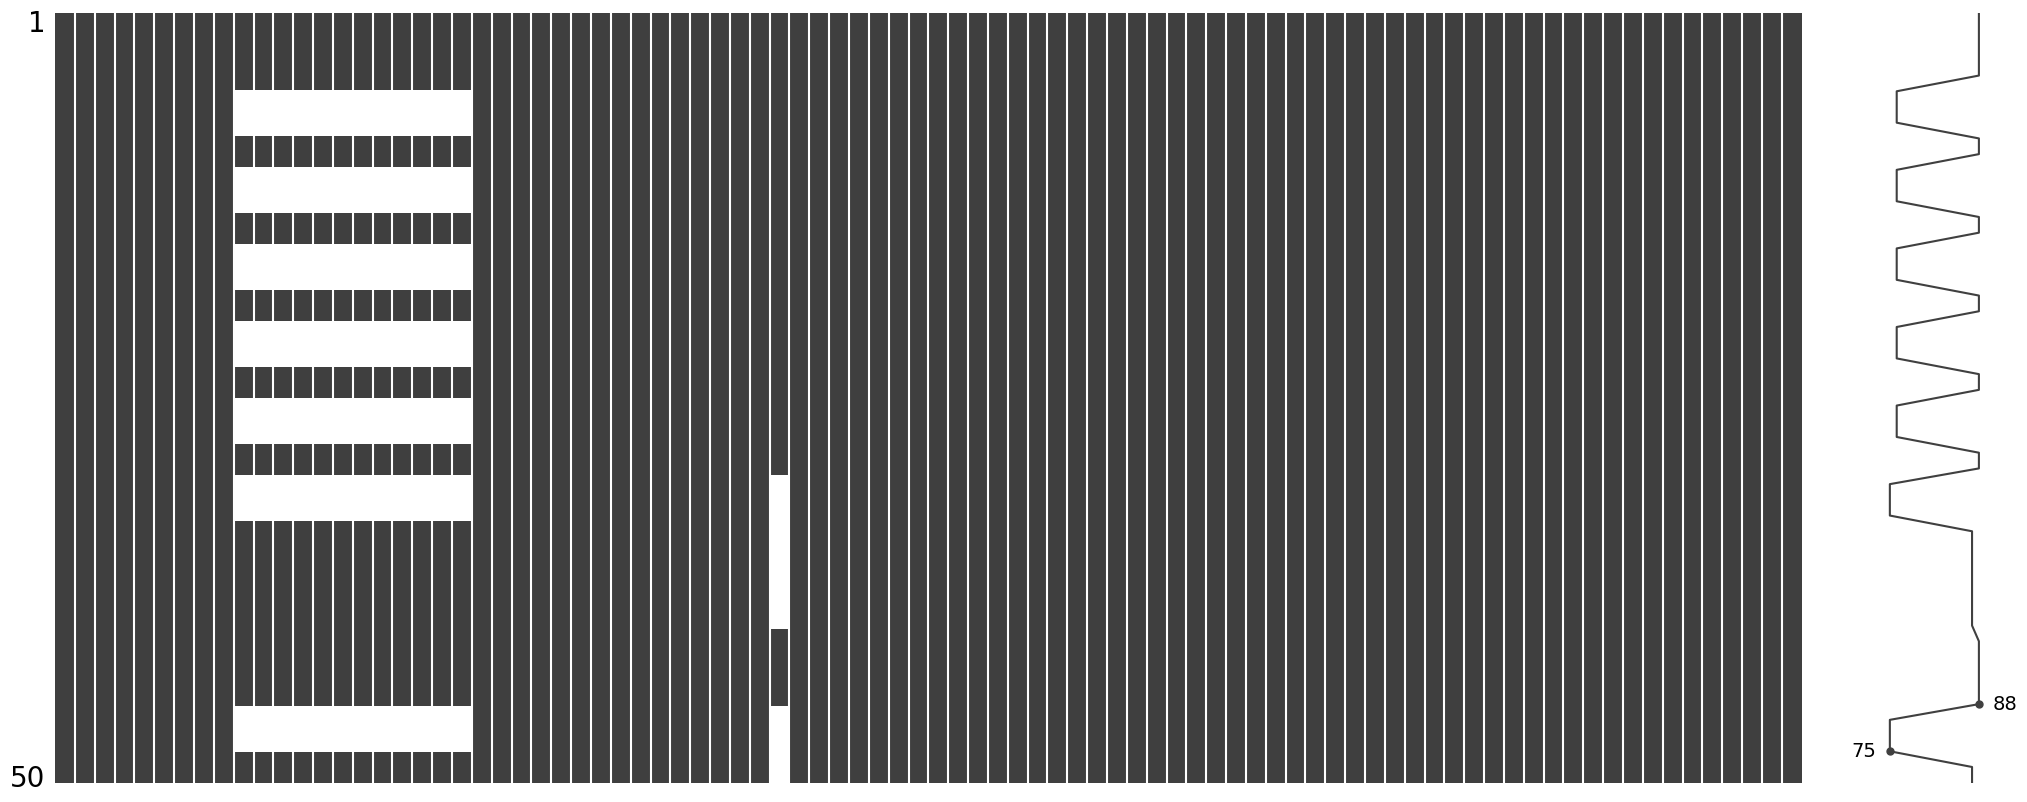

In [92]:
missingno.matrix(merged)

In [93]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

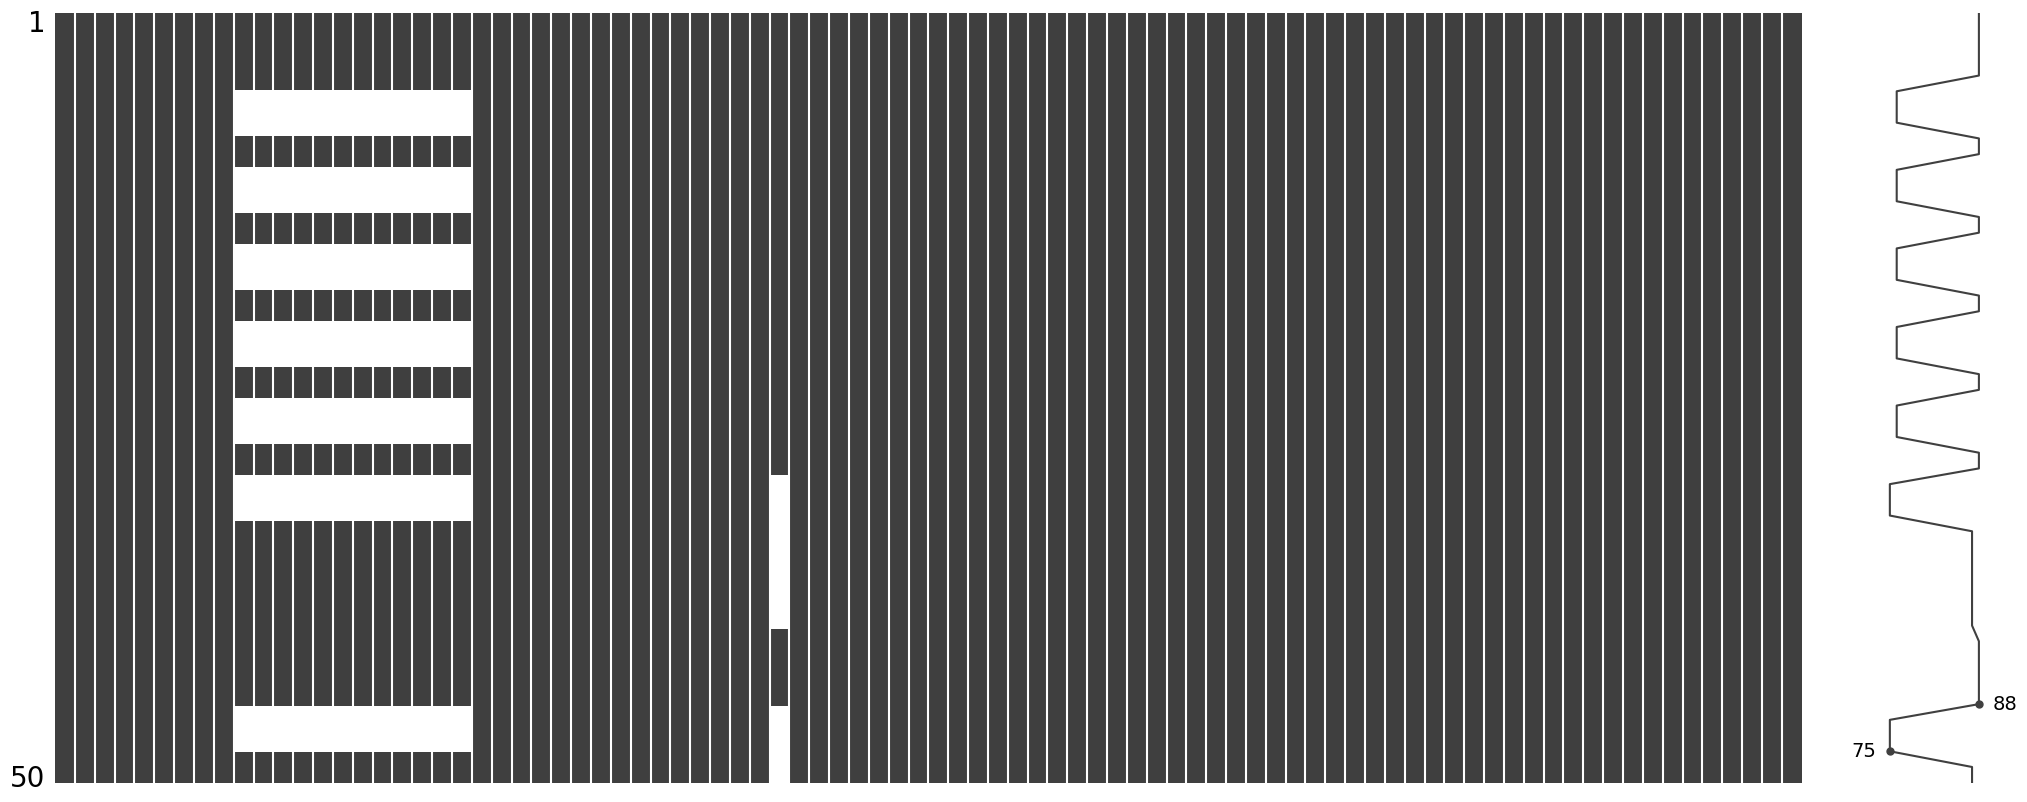

In [94]:
missingno.matrix(merged)

In [95]:
years = merged.year.unique()
years

array([2024], dtype=int64)

In [96]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['εβρος', 'ξανθη', 'ροδοπη', 'δραμα', 'θασος, καβαλα'], dtype=object)

In [97]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [98]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,εβρος,2024,19.600000,20.400000,45.333333,882.483868,42.000000,-3.000000,45.000000,16.833333,29.500000,29.500000,8.833333,245.000000,93.000000,0.000000,130.303261,202.000000,0.000000,0.000000,85.000000
1,ξανθη,2024,17.550000,17.500000,41.666667,849.983660,39.000000,-3.000000,42.000000,15.500000,27.000000,27.000000,7.166667,242.000000,81.000000,0.000000,120.505477,190.000000,0.000000,0.000000,94.000000
2,ροδοπη,2024,19.050000,19.300000,44.883721,872.878380,41.000000,-2.000000,43.000000,16.500000,28.833333,28.833333,8.333333,188.000000,85.000000,0.000000,139.493125,160.000000,0.000000,0.000000,67.000000
3,δραμα,2024,15.950000,17.500000,42.682927,799.461624,37.000000,-4.000000,41.000000,14.166667,25.166667,25.166667,6.666667,212.000000,78.000000,0.000000,117.344047,154.000000,0.000000,0.000000,79.000000
4,"θασος, καβαλα",2024,18.550000,17.300000,42.195122,827.126888,39.000000,-2.000000,41.000000,16.500000,27.833333,27.833333,8.333333,379.000000,153.000000,0.000000,129.090202,292.000000,0.000000,0.000000,226.000000


In [99]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [100]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['NUTS3_NAME'] == 'εβρος')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2024,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,8.574981,1.385448,4.980215,8.574981,13.670966,15.738171,24.153030,1.385448,5.262983,5.423026,11.262653,4.980215,9.466974,10.580598,17.707842,0.464180,0.301116,2.139040,14.380588,14.389570,2675.583333,86.309140,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570,0,19.600000,20.400000,45.333333,882.483868,42.000000,-3.000000,45.000000,16.833333,29.500000,29.500000,8.833333,245.000000,93.000000,0.000000,130.303261,202.000000,0.000000,0.000000,85.000000
5,2024-02,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,2,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.670966,5.262983,9.466974,8.574981,13.670966,15.738171,24.153030,1.385448,5.262983,5.423026,11.262653,4.980215,9.466974,10.580598,17.707842,1.021080,1.452798,1.851397,29.611326,44.000896,2327.450980,80.256930,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,18.766100,29.611326,0,19.600000,20.400000,45.333333,882.483868,42.000000,-3.000000,45.000000,16.833333,29.500000,29.500000,8.833333,245.000000,93.000000,0.000000,130.303261,202.000000,0.000000,0.000000,85.000000
10,2024-03,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.738171,5.423026,10.580598,8.574981,13.670966,15.738171,24.153030,1.385448,5.262983,5.423026,11.262653,4.980215,9.466974,10.580598,17.707842,1.361035,1.133893,3.461768,39.623695,86.192970,3451.264706,111.331120,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,1.076800,25.613600,42.192074,0,19.600000,20.400000,

In [101]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [102]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [103]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [104]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [105]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

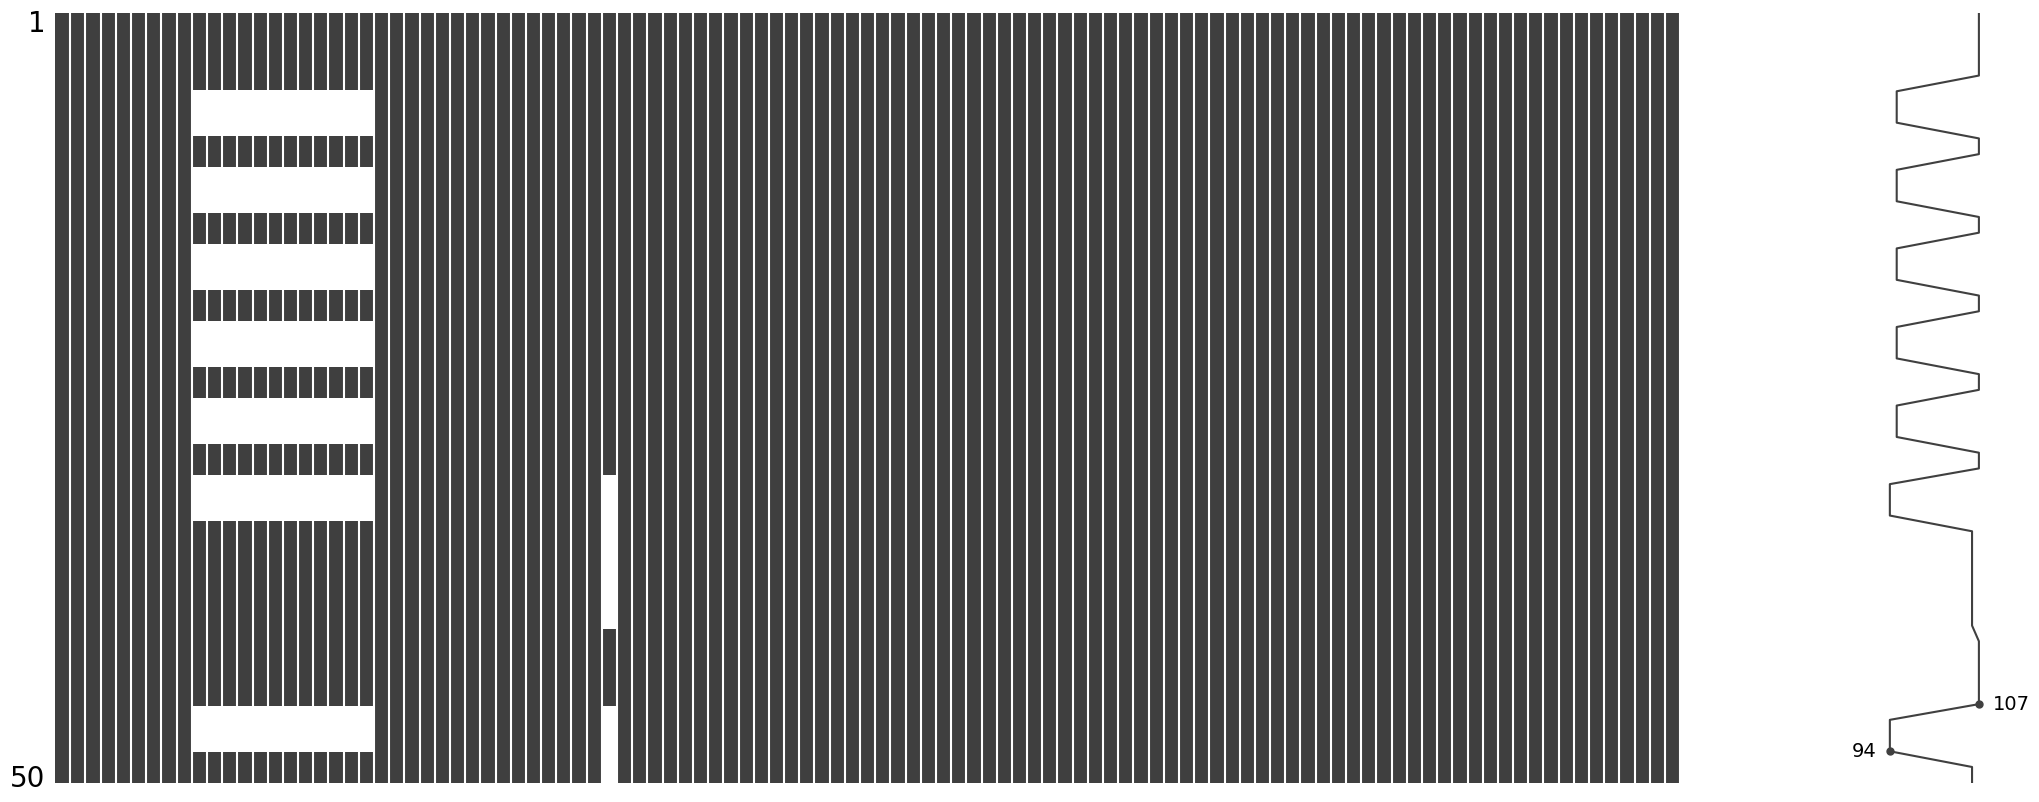

In [106]:
missingno.matrix(dataset)

In [107]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [108]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [109]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [110]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [111]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

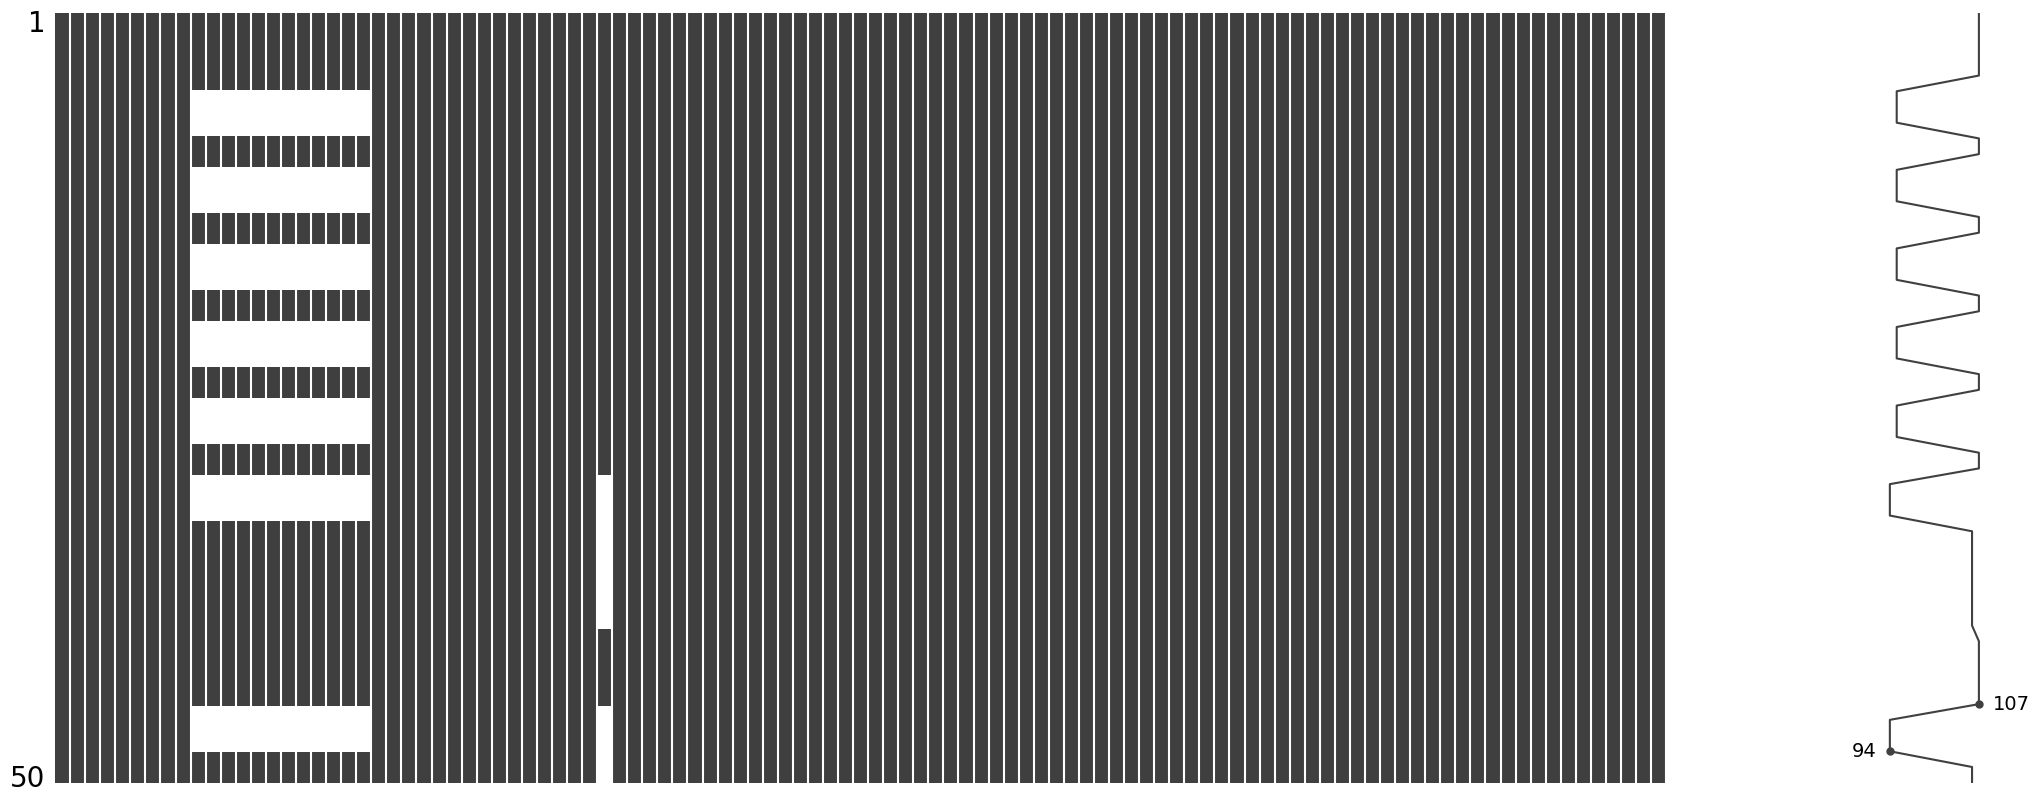

In [112]:
missingno.matrix(dataset)

In [113]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [114]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [115]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [116]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [117]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

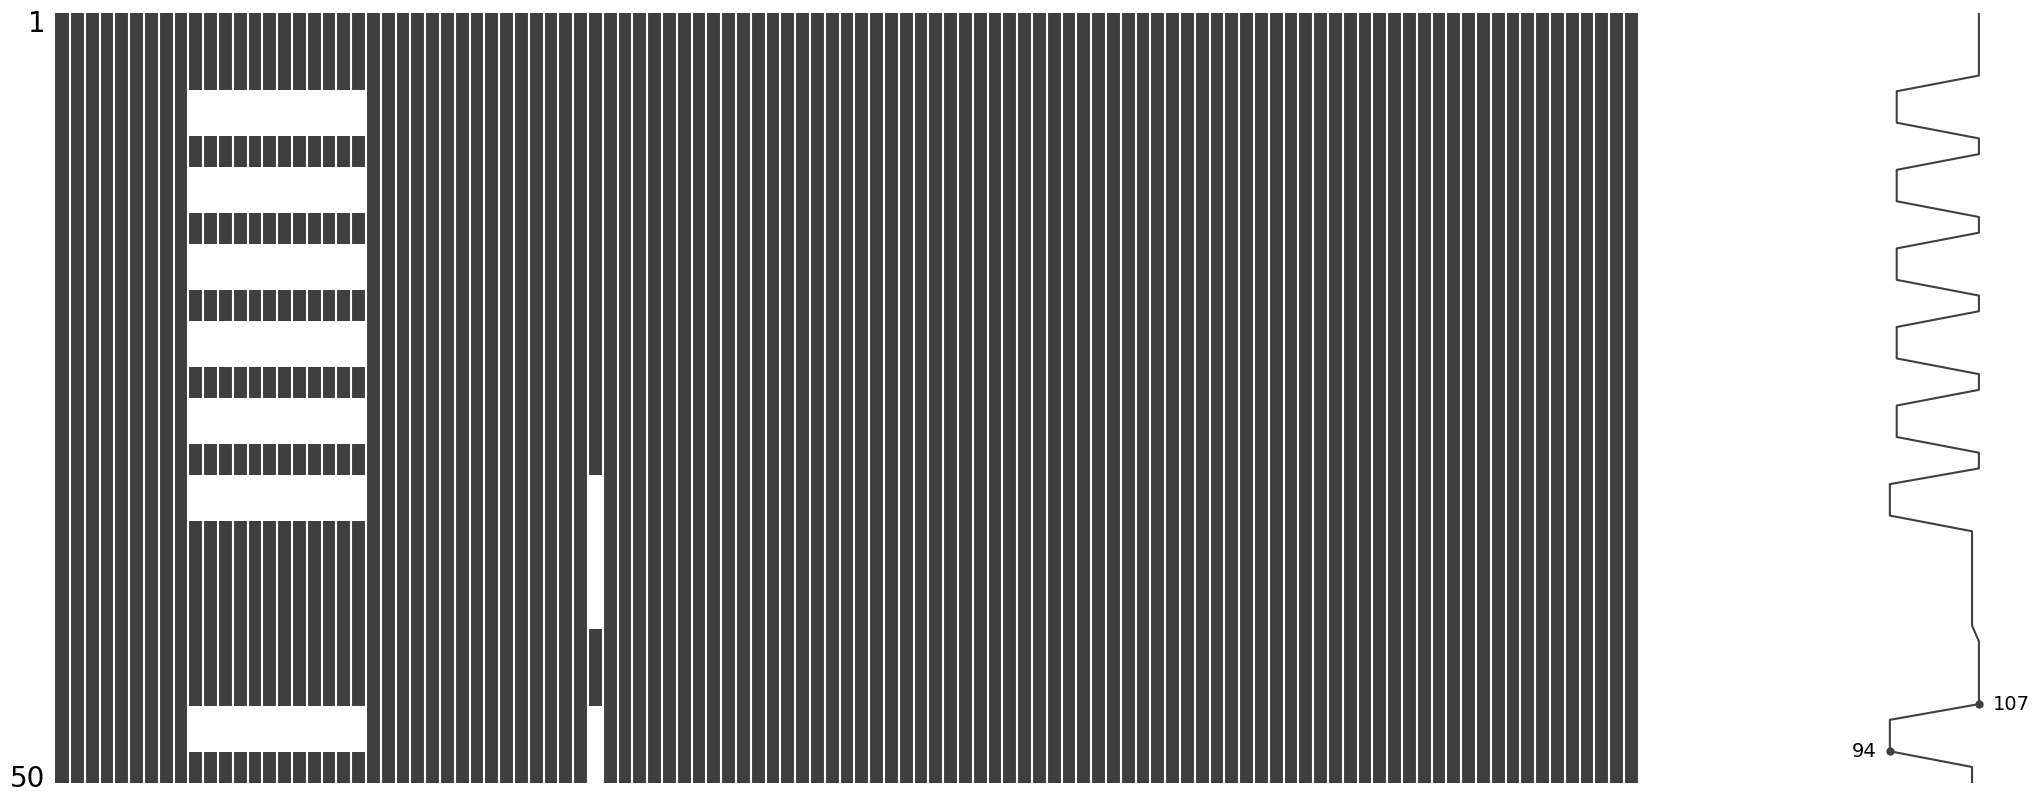

In [118]:
missingno.matrix(dataset)

In [119]:
missing = describe_dataframe(dataset)

In [120]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
113,F_Y_GE65,100.000000
114,F_TOTAL,100.000000
115,MIO_EUR,100.000000
116,L_TOTAL,100.000000


In [121]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2024,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,8.574981,1.385448,4.980215,8.574981,13.670966,15.738171,24.153030,1.385448,5.262983,5.423026,11.262653,4.980215,9.466974,10.580598,17.707842,0.464180,0.301116,2.139040,14.380588,14.389570,2675.583333,86.309140,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570,0,19.600000,20.400000,45.333333,882.483868,42.000000,-3.000000,45.000000,16.833333,29.500000,29.500000,8.833333,245.000000,93.000000,0.000000,130.303261,202.000000,0.000000,0.000000,85.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2024,0.250112,-0.078340,-0.240289,0.078340,0.211850,-0.064113,-0.188633,0.064113,0.049435,0.044058,0.071612,0.044058,7.834355,0.107669,3.971012,7.834355,11.927052,14.937185,23.048017,0.107669,3.481793,5.262008,11.293875,3.971012,7.704422,10.099597,17.170946,0.421900,0.596450,2.341214,13.078887,13.078887,1821.350000,58.753226,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-3.572000,11.836250,13.078887,0,17.550000,17.500000,41.666667,849.983660,39.000000,-3.000000,42.000000,15.500000,27.000000,27.000000,7.166667,242.000000,81.000000,0.000000,120.505477,190.000000,0.000000,0.000000,94.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2024,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,8.842674,1.086363,4.964519,8.842674,12.980701,16.038085,23.693688,1.086363,4.841568,5.500957,11.512516,4.964519,8.911135,10.769521,17.603102,0.387606,0.574626,2.705965,12.015796,12.015796,1564.612903,50.471384,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,3

In [122]:
dataset.reset_index(inplace=True, drop=True)

In [123]:
dataset['cases'].value_counts()

cases
0    50
Name: count, dtype: int64

In [124]:
dataset['cases'].sum()

0

In [125]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2024,0.236196,-0.103672,-0.199583,0.103672,0.228260,-0.108220,-0.193680,0.108220,0.048977,0.047546,0.051556,0.047546,8.574981,1.385448,4.980215,8.574981,13.670966,15.738171,24.153030,1.385448,5.262983,5.423026,11.262653,4.980215,9.466974,10.580598,17.707842,0.464180,0.301116,2.139040,14.380588,14.389570,2675.583333,86.309140,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-3.237200,15.714500,14.389570,0,19.600000,20.400000,45.333333,882.483868,42.000000,-3.000000,45.000000,16.833333,29.500000,29.500000,8.833333,245.000000,93.000000,0.000000,130.303261,202.000000,0.000000,0.000000,85.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2024,0.250112,-0.078340,-0.240289,0.078340,0.211850,-0.064113,-0.188633,0.064113,0.049435,0.044058,0.071612,0.044058,7.834355,0.107669,3.971012,7.834355,11.927052,14.937185,23.048017,0.107669,3.481793,5.262008,11.293875,3.971012,7.704422,10.099597,17.170946,0.421900,0.596450,2.341214,13.078887,13.078887,1821.350000,58.753226,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-3.572000,11.836250,13.078887,0,17.550000,17.500000,41.666667,849.983660,39.000000,-3.000000,42.000000,15.500000,27.000000,27.000000,7.166667,242.000000,81.000000,0.000000,120.505477,190.000000,0.000000,0.000000,94.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2024,0.254835,0.004974,-0.205910,-0.004974,0.213309,0.006266,-0.162210,-0.006266,0.046484,0.049882,0.053799,0.049882,8.842674,1.086363,4.964519,8.842674,12.980701,16.038085,23.693688,1.086363,4.841568,5.500957,11.512516,4.964519,8.911135,10.769521,17.603102,0.387606,0.574626,2.705965,12.015796,12.015796,1564.612903,50.471384,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,3

In [126]:
cols = dataset.columns

In [127]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=118)


In [128]:
len(cols)

118

In [129]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2024.csv", encoding = enc, index = False)
